# Exploration: PET End-of-Life Pathway Results

This notebook loads the Monte Carlo simulation results produced by `src/uncertainty.py`
and explores them interactively. It is meant as a companion to the `src/` scripts,
not a replacement — the reproducible pipeline lives in `.py` files; this notebook is
for ad-hoc exploration, sanity checks, and quick additional plots.

Run `python src/uncertainty.py` first (from the `src/` folder) so that
`results/tables/uncertainty_summary.csv` exists before running this notebook.

In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt

# allow importing from src/
sys.path.append(os.path.join("..", "src"))

from uncertainty import run_simulation, N_SIMULATIONS
from parameters import UNCERTAINTY_RANGES

## 1. Load the saved summary table

This is the CSV already generated by `uncertainty.py` — a quick way to check
the headline numbers without re-running the full simulation.

In [2]:
summary = pd.read_csv(os.path.join("..", "results", "tables", "uncertainty_summary.csv"))
summary

,pathway,mean_kg_co2e,std_dev_kg_co2e,min_kg_co2e,max_kg_co2e,win_count,win_percent
0,Mechanical Recycling,-935.546,147.281,-1392.896,-551.023,4726,94.52
1,Chemical Recycling,-473.422,200.767,-1177.006,-25.084,162,3.24
2,Energy Recovery,502.104,709.770,-1501.329,2230.906,112,2.24
3,Landfill,54.822,14.728,30.006,79.989,0,0.00


## 2. Re-run the simulation directly

Useful for exploring the raw per-run values rather than just the summary stats
(e.g. looking at the full distribution, not just mean/std/min/max).

In [3]:
results, win_counts = run_simulation()

# quick look at the first few raw values for mechanical recycling
results["Mechanical Recycling"][:10]

[-1046.3607627655317,
 -1148.9896915313395,
 -884.1283958619326,
 -770.5458241927032,
 -741.252914865538,
 -979.154338587218,
 -747.5462291709921,
 -997.1875441601854,
 -1115.1710333104777,
 -956.797369914707]

## 3. Histogram of outcomes per pathway

The box plots in `results/figures/box_comparison.png` show quartiles well,
but a histogram makes the full shape of the distribution easier to see —
in particular how "peaked" mechanical recycling's result is compared to
the long tail on energy recovery.

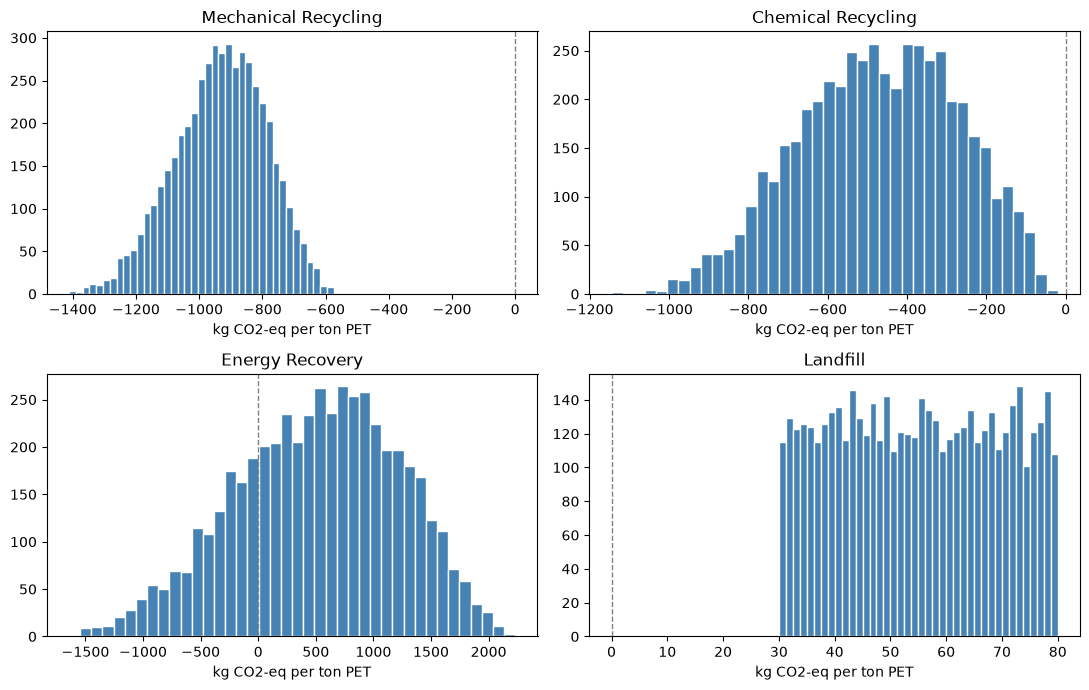

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=False)
axes = axes.flatten()

for ax, (name, values) in zip(axes, results.items()):
    ax.hist(values, bins=40, color="steelblue", edgecolor="white")
    ax.axvline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_title(name)
    ax.set_xlabel("kg CO2-eq per ton PET")

plt.tight_layout()
plt.show()

## 4. When does mechanical recycling *not* win?

Mechanical recycling wins ~94% of simulations. This looks at the specific
parameter draws from the remaining ~6% to see what conditions cause another
pathway to come out ahead — this is more informative than the win-rate
percentage alone, since it identifies *which* assumptions matter most.

In [5]:
import random

random.seed(42)  # reproducible for this inspection

losing_runs = []

for _ in range(N_SIMULATIONS):
    mech_params = {k: random.uniform(*v) for k, v in UNCERTAINTY_RANGES["mechanical"].items()}
    chem_params = {k: random.uniform(*v) for k, v in UNCERTAINTY_RANGES["chemical"].items()}
    energy_params = {k: random.uniform(*v) for k, v in UNCERTAINTY_RANGES["energy"].items()}
    landfill_params = {k: random.uniform(*v) for k, v in UNCERTAINTY_RANGES["landfill"].items()}

    from model import mechanical_recycling, chemical_recycling, energy_recovery, landfill

    run_results = {
        "Mechanical Recycling": mechanical_recycling(mech_params),
        "Chemical Recycling": chemical_recycling(chem_params),
        "Energy Recovery": energy_recovery(energy_params),
        "Landfill": landfill(landfill_params),
    }

    winner = min(run_results, key=run_results.get)
    if winner != "Mechanical Recycling":
        losing_runs.append({**mech_params, "winner": winner})

losing_df = pd.DataFrame(losing_runs)
print(f"{len(losing_df)} out of {N_SIMULATIONS} runs where mechanical recycling did not win")
losing_df.describe()

283 out of 5000 runs where mechanical recycling did not win


,collection_rate,sorting_yield,process_yield,rpet_emission_factor,virgin_emission_factor,landfill_emission_factor
count,283.000000,283.000000,283.000000,283.000000,283.000000,283.000000
mean,0.685033,0.860006,0.892945,0.497099,2.070194,0.053592
std,0.064005,0.041472,0.028460,0.067471,0.140051,0.014706
min,0.600242,0.800666,0.850412,0.350688,1.900286,0.030074
25%,0.632669,0.826634,0.867938,0.446465,1.952954,0.039922
50%,0.670510,0.848898,0.888372,0.502221,2.022429,0.053354
75%,0.720670,0.894839,0.914872,0.556206,2.155464,0.066616
max,0.846602,0.949703,0.949671,0.599732,2.398842,0.079781


**Takeaway:** comparing the `describe()` output above against the baseline
mechanical-recycling parameters in `parameters.py` shows which inputs tend to
be pushed toward their unfavorable extreme (e.g. lower `collection_rate` or
`process_yield`) in the runs where mechanical recycling loses its advantage.
This is the basis for the discussion point in the final report: the pathway
ranking is robust, but not unconditionally so.